**BEUST Léna**

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

### Loading Data

In [2]:
training_data = datasets.CIFAR10(root="data", train=True, download=True, transform=ToTensor())
test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=ToTensor())

classes = training_data.classes
print(classes)

100%|██████████| 170M/170M [00:04<00:00, 39.4MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
training_data, validation_data = torch.utils.data.random_split(training_data, [40000, 10000])

In [4]:
print(len(training_data),len(validation_data),len(test_data))

40000 10000 10000


## **Simple CNN**

  ### **~ Model 1 ~**

In [5]:
def simple_cnn(units = [3*32*32, 10]):
    model = torch.nn.Sequential()
    model.add_module('conv_1', torch.nn.Conv2d(in_channels= 3, out_channels= 32, kernel_size=3, padding='same', stride = 1))
    model.add_module('relu_2', torch.nn.ReLU())
    model.add_module('maxpool_3', torch.nn.MaxPool2d(kernel_size= 2, stride= 2))
    model.add_module('flatten_4', torch.nn.Flatten())   # flatten before last layer
    model.add_module('linear_5', torch.nn.Linear(16*16*32, units[1]))
    model.add_module('softmax_6', torch.nn.Softmax(dim = 1))
    return model

In [6]:
def train_eval(model, lr, nepochs, nbatch, training_data, validation_data, output=True):
    cost_hist = []
    cost_hist_test = []
    acc_hist = []
    acc_hist_test = []

    cost_ce = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
    test_loader = DataLoader(validation_data, batch_size=nbatch, shuffle=True)

    for epoch in range(nepochs):
        start=time.time()
        model.train()
        size = len(training_loader.dataset)
        nbatches = len(training_loader)
        cost, acc = 0.0, 0.0
        for batch, (X, Y) in enumerate(training_loader):
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        cost /= nbatches
        acc /= size

        model.eval()
        size_test = len(test_loader.dataset)
        nbatches_test = len(test_loader)
        cost_test, acc_test = 0.0, 0.0
        with torch.no_grad():
            for X, Y in test_loader:
                pred = model(X)
                cost_test += cost_ce(pred, Y).item()
                acc_test += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
        cost_test /= nbatches_test
        acc_test /= size_test
        end=time.time()
        if output:
            print("Epoch %i (dt=%1.2f s): %f, %f, %f, %f"%(epoch, end-start, cost, acc, cost_test, acc_test))
        cost_hist.append(cost)
        cost_hist_test.append(cost_test)
        acc_hist.append(acc)
        acc_hist_test.append(acc_test)
    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
         MaxPool2d-3           [-1, 32, 16, 16]               0
           Flatten-4                 [-1, 8192]               0
            Linear-5                   [-1, 10]          81,930
           Softmax-6                   [-1, 10]               0
Total params: 82,826
Trainable params: 82,826
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.63
Params size (MB): 0.32
Estimated Total Size (MB): 0.95
----------------------------------------------------------------
Epoch 0 (dt=32.17 s): 2.134694, 0.328900, 2.088396, 0.377400
Epoch 1 (dt=30.73 s): 2.067608, 0.398625, 2.028815, 0.442200
Epoch 2 (dt=31.32 s): 1.988775, 0.483650, 1.970785

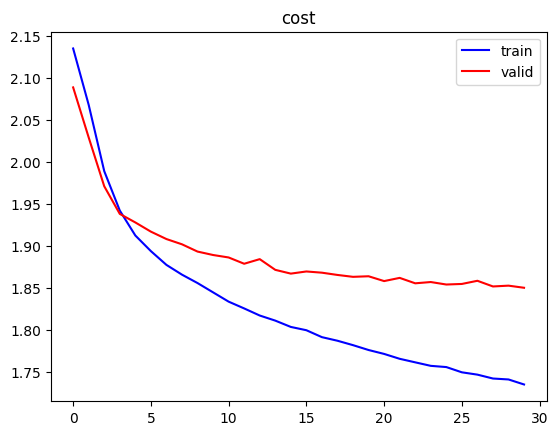

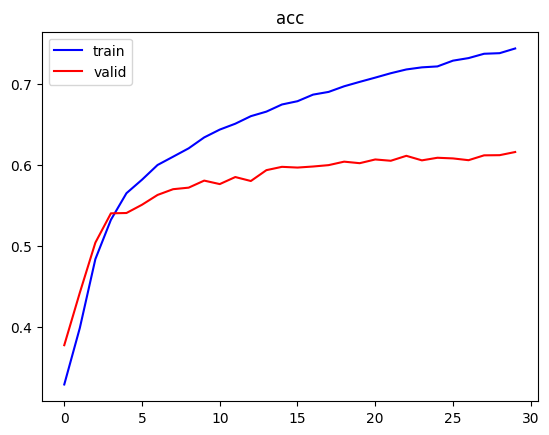

test accuracy: 61.9%


In [7]:
nbatch = 128
nepochs = 30
lr = 0.001

size_in = training_data[0][0].shape
simple_cnn_model = simple_cnn()
summary(simple_cnn_model, size_in)

cost_train, cost_valid, acc_train, acc_valid = train_eval(simple_cnn_model, lr, nepochs,
                                nbatch, training_data, validation_data)

plt.figure(1)
plt.plot(range(len(cost_train)), cost_train, "b-", label='train')
plt.plot(range(len(cost_valid)), cost_valid, "r-", label='valid')
plt.legend()
plt.title('cost')
plt.show()

plt.figure(2)
plt.plot(range(len(acc_train)), acc_train, "b-", label='train')
plt.plot(range(len(acc_valid)), acc_valid, "r-", label='valid')
plt.legend()
plt.title('acc')
plt.show()

len_test = len(test_data)
test_loader = DataLoader(test_data, batch_size=len_test, shuffle=False)
X, Y = next(iter(test_loader))
pred = simple_cnn_model(X)

acc_test = (pred.argmax(dim=1) == Y).type(torch.float).sum().item() / len_test

print(f'test accuracy: {100*acc_test:.1f}%')

> We obtain an accuracy of 61.9 % for the test. This is far more better than the accuracy of 46% with an MLP.

## **Deeper CNN**





### **~ Model 2~**

Adding a Conv2D and a Maxpool layer.

In [8]:
def deeper_cnn(units = [3*32*32, 10]):
    model = torch.nn.Sequential()
    model.add_module(f'conv1', torch.nn.Conv2d(in_channels=3, out_channels = 32, stride = 1, kernel_size=3,padding ='same'))
    model.add_module(f'batchnormalisation', torch.nn.BatchNorm2d(32))
    model.add_module(f'relu', torch.nn.ReLU())
    model.add_module(f'2dpool', torch.nn.MaxPool2d(kernel_size=2, stride=2)) #quand stride n'est pas spécifiée ca fait automatiquement kernel.size
    #downsampling operation along the spatial dimensions
    model.add_module(f'conv2', torch.nn.Conv2d(in_channels=32, out_channels = 32, stride = 1, kernel_size=3,padding ='same'))
    model.add_module(f'batchnormalisation', torch.nn.BatchNorm2d(32))
    model.add_module('relu_5', torch.nn.ReLU())
    model.add_module('maxpool_6', torch.nn.MaxPool2d(kernel_size= 2, stride= 2))#réduit hauteur et largeur mais pas le nombre de cannaux
    model.add_module(f'flatten', torch.nn.Flatten())
    model.add_module(f'layer', torch.nn.Linear(8*8*32,1*1*10)) #on passe du layer dense à 1*1*10 des classes
    model.add_module(f'softmax', torch.nn.Softmax(dim=1)) #la dimension sert à faire entre les classes et pas les exemples du batch

    return model #la régularisation L2 se mettra dans l'apprentissage

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
         MaxPool2d-4           [-1, 32, 16, 16]               0
            Conv2d-5           [-1, 32, 16, 16]           9,248
              ReLU-6           [-1, 32, 16, 16]               0
         MaxPool2d-7             [-1, 32, 8, 8]               0
           Flatten-8                 [-1, 2048]               0
            Linear-9                   [-1, 10]          20,490
          Softmax-10                   [-1, 10]               0
Total params: 30,698
Trainable params: 30,698
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.97
Params size (MB): 0.12
Estimated Tot

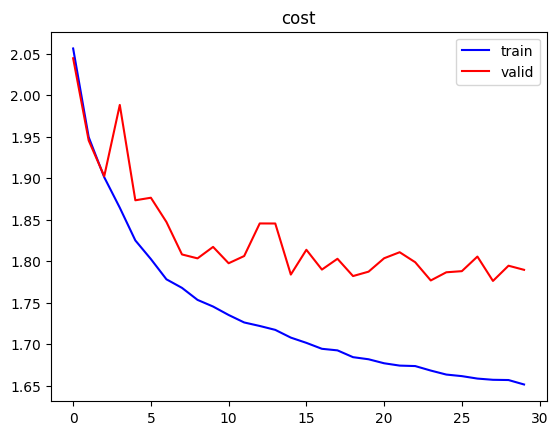

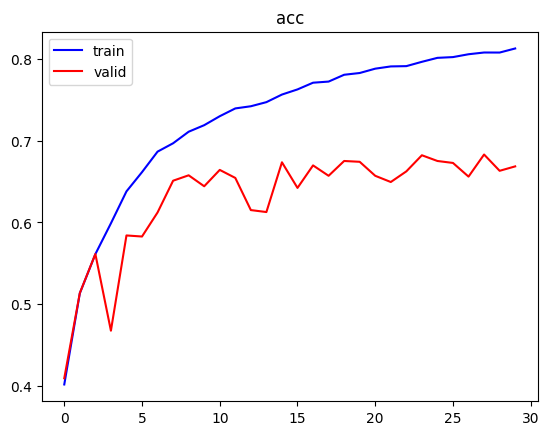

test accuracy: 67.1%


In [9]:
nbatch = 128
nepochs = 30
lr = 0.001

size_in = training_data[0][0].shape
deeper_cnn_model = deeper_cnn()
summary(deeper_cnn_model, size_in)

cost_train2, cost_valid2, acc_train2, acc_valid2 = train_eval(deeper_cnn_model, lr, nepochs,
                                nbatch, training_data, validation_data)

plt.figure(1)
plt.plot(range(len(cost_train2)), cost_train2, "b-", label='train')
plt.plot(range(len(cost_valid2)), cost_valid2, "r-", label='valid')
plt.legend()
plt.title('cost')
plt.show()

plt.figure(2)
plt.plot(range(len(acc_train2)), acc_train2, "b-", label='train')
plt.plot(range(len(acc_valid2)), acc_valid2, "r-", label='valid')
plt.legend()
plt.title('acc')
plt.show()

len_test = len(test_data)
test_loader = DataLoader(test_data, batch_size=len_test, shuffle=False)
X, Y = next(iter(test_loader))
pred2 = deeper_cnn_model(X)

acc_test2 = (pred2.argmax(dim=1) == Y).type(torch.float).sum().item() / len_test

print(f'test accuracy: {100*acc_test2:.1f}%')

> We obtain an accuracy of 67.1% for the test.

### **~ Model 3 ~**
And increasing the size of the kernel

In [10]:
def deeper_cn2(units = [3*32*32, 10]):

    model = torch.nn.Sequential()
    model.add_module(f'conv1', torch.nn.Conv2d(in_channels=3, out_channels = 32, stride = 1, kernel_size=5,padding ='same'))
    model.add_module(f'batchnormalisation', torch.nn.BatchNorm2d(32))
    model.add_module(f'relu', torch.nn.ReLU())
    model.add_module(f'2dpool', torch.nn.MaxPool2d(kernel_size=2, stride=2))
    model.add_module(f'conv2', torch.nn.Conv2d(in_channels=32, out_channels = 32, stride = 1, kernel_size=5,padding ='same'))
    model.add_module(f'batchnormalisation', torch.nn.BatchNorm2d(32))
    model.add_module('relu_5', torch.nn.ReLU())
    model.add_module('maxpool_6', torch.nn.MaxPool2d(kernel_size= 2, stride= 2))
    model.add_module(f'flatten', torch.nn.Flatten())
    model.add_module(f'layer', torch.nn.Linear(8*8*32,1*1*10))
    model.add_module(f'softmax', torch.nn.Softmax(dim=1))

    return model

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
         MaxPool2d-4           [-1, 32, 16, 16]               0
            Conv2d-5           [-1, 32, 16, 16]           9,248
              ReLU-6           [-1, 32, 16, 16]               0
         MaxPool2d-7             [-1, 32, 8, 8]               0
           Flatten-8                 [-1, 2048]               0
            Linear-9                   [-1, 10]          20,490
          Softmax-10                   [-1, 10]               0
Total params: 30,698
Trainable params: 30,698
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.97
Params size (MB): 0.12
Estimated Tot

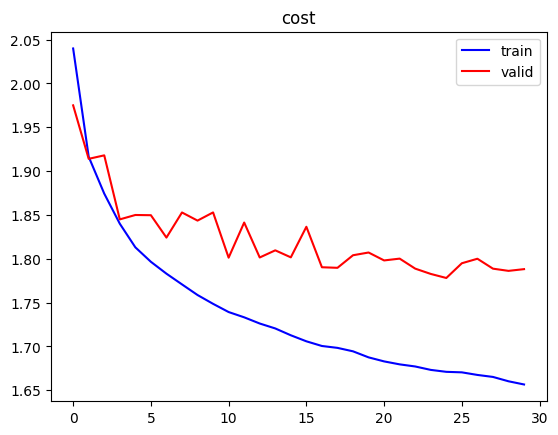

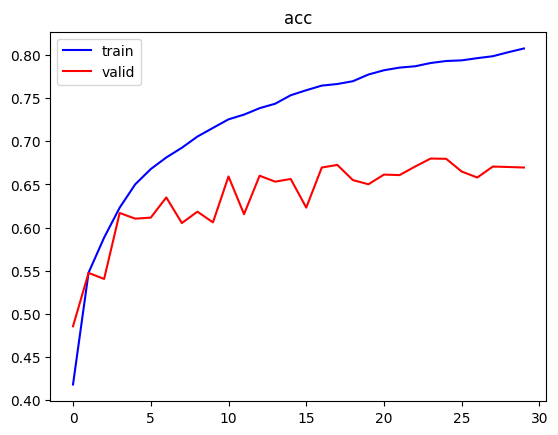

test accuracy: 67.2%


In [11]:
nbatch = 128
nepochs = 30
lr = 0.001

size_in = training_data[0][0].shape
deeper_cnn_2 = deeper_cnn()
summary(deeper_cnn_2, size_in)

cost_train3, cost_valid3, acc_train3, acc_valid3 = train_eval(deeper_cnn_2, lr, nepochs,
                                nbatch, training_data, validation_data)

plt.figure(1)
plt.plot(range(len(cost_train3)), cost_train3, "b-", label='train')
plt.plot(range(len(cost_valid3)), cost_valid3, "r-", label='valid')
plt.legend()
plt.title('cost')
plt.show()

plt.figure(2)
plt.plot(range(len(acc_train3)), acc_train3, "b-", label='train')
plt.plot(range(len(acc_valid3)), acc_valid3, "r-", label='valid')
plt.legend()
plt.title('acc')
plt.show()

len_test = len(test_data)
test_loader = DataLoader(test_data, batch_size=len_test, shuffle=False)
X, Y = next(iter(test_loader))
pred3 = deeper_cnn_2(X)

acc_test3 = (pred3.argmax(dim=1) == Y).type(torch.float).sum().item() / len_test

print(f'test accuracy: {100*acc_test3:.1f}%')

> We obtain an accuracy of 67.2% for the test.

 **Model 1** :    Simple CNN


1.   Conv : in = 3, out = 32, S = 1, P = 'same', kernel_size = 3
2.   ReLU
3.   Maxpool : kernel_size= 2, S = 2
4.   Flatten
5.   Linear
6.   Softmax

>> **acc train** : 74.4%

>> **acc test** :  61.9 %


 **Model 2** : Deeper CNN


1.   Conv : in = 3, out = 32, S = 1, P = 'same', kernel_size = 3
2.   BatchNormalisation
3.   ReLU
3.   Maxpool : kernel_size= 2, S = 2
4.   Conv : in = 32, out = 32, S = 1, P = 'same', kernel_size = 3
5.   BatchNormalisation
6.   ReLU
6.   Maxpool : kernel_size= 2, S = 2
10.   Flatten
11.   Linear
12.   Softmax

>> **acc train** : 81.3%

>> **acc test** : 67.1%



 **Model 3** :    Deeper CNN 2

1.   Conv : in = 3, out = 32, S = 1, P = 'same', kernel_size = 5
2.   BatchNormalisation
3.   ReLU
3.   Maxpool : kernel_size= 2, S = 2
4.   Conv : in = 32, out = 32, S = 1, P = 'same', kernel_size = 5
5.   BatchNormalisation
6.   ReLU
6.   Maxpool : kernel_size= 2, S = 2
10.   Flatten
11.   Linear
12.   Softmax

>> **acc train** : 80.8%

>> **acc test** : 67.2%
